# Anomaly Clustering

Cluster anomalies detected by Transformer+OC-SVM, PNN (spoofing gain), and PRAE (RFDR).

In [1]:
import os
import sys
import glob
import json
import logging
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import joblib

from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from torch.utils.data import DataLoader, TensorDataset

sys.path.insert(0, os.path.abspath(".."))

from detection.data.loaders import create_sequences, load_processed
from detection.data.preprocessing import get_time_frac, assign_period
from detection.models import hybrid, pnn as pnn_module, prae as prae_module
from detection.models.transformer import BottleneckTransformer
from detection.spoofing.gain import compute_spoofing_gains_batch
from detection.thresholds.rfdr import RollingFalseDiscoveryRate
from detection.trainers.factory import load_model

logging.basicConfig(
    level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s"
)
logger = logging.getLogger(__name__)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
TRAIN_YEAR = 2015
# --- Subsample mode: set to None to use full data ---
MAX_ROWS = 200_000  # rows per file (must be > SEQ_LENGTH)

DATA_DIR = os.path.join("..", "data", "processed", "TOTF.PA-book")
RESULTS_DIR = os.path.join("..", "results", str(TRAIN_YEAR))
OUTPUT_DIR = os.path.join("..", "results", str(TRAIN_YEAR), "test_output")
MODEL_TYPES = ["transformer_ocsvm", "pnn", "prae"]

FILES = sorted(glob.glob(os.path.join(DATA_DIR, "*.parquet")))
TEST_FILES = [FILES[22], FILES[23], FILES[24], FILES[25], FILES[26]] # Last 3 files of 2015, first two of 2017
TEST_FILES = [FILES[22]]


SEQ_LENGTH = 25
BATCH_SIZE = 64

LOB_COLUMNS = [
    f"{side}-{typ}-{lvl}"
    for lvl in range(1, 11)
    for side, typ in [
        ("bid", "price"),
        ("bid", "volume"),
        ("ask", "price"),
        ("ask", "volume"),
    ]
]

SPOOF_Q = 4500
SPOOF_q = 100
SPOOF_DELTA_A = 0.0
SPOOF_DELTA_B = 0.01
SPOOF_FEES = {"maker": 0.0, "taker": 0.05}

RFDR_WINDOW = 500
RFDR_ALPHA = 0.05

PERIODS = {
    "1st_hour": (9.0, 10.0),
    "rest_of_morning": (10.0, 12.0),
    "afternoon": (12.0, 15.5),
    "american_open": (15.5, 17.5),
}

KMEANS_K_RANGE = range(2, 7)
RANDOM_STATE = 42

# Check for pre-computed results from test.py / testing notebook
_saved_meta_path = os.path.join(OUTPUT_DIR, "test_meta.json")
SAVED_RESULTS_AVAILABLE = (
    os.path.exists(_saved_meta_path)
    and all(os.path.exists(os.path.join(OUTPUT_DIR, f"{mt}_scores.npy")) for mt in MODEL_TYPES)
)
if SAVED_RESULTS_AVAILABLE:
    with open(_saved_meta_path) as _f:
        _saved_meta = json.load(_f)
    _saved_files = set(_saved_meta.get("test_files", []))
    _current_files = {os.path.basename(f) for f in TEST_FILES}
    # Only use saved results if the test files are a superset (saved includes current)
    SAVED_RESULTS_AVAILABLE = _current_files.issubset(_saved_files) and MAX_ROWS is None
    if SAVED_RESULTS_AVAILABLE:
        print(f"Pre-computed results found in {OUTPUT_DIR}. Will load scores & preds.")
    else:
        print(f"Pre-computed results exist but test files differ or MAX_ROWS set. Will recompute.")
else:
    print("No pre-computed results found. Will compute from scratch.")

No pre-computed results found. Will compute from scratch.


In [3]:
feature_names_map = {}
for mt in MODEL_TYPES:
    feat_path = os.path.join(RESULTS_DIR, f"{mt}_features.txt")
    if os.path.exists(feat_path):
        with open(feat_path) as fh:
            feature_names_map[mt] = [ln.strip() for ln in fh if ln.strip()]
    else:
        _, tmp = load_processed(TEST_FILES[0], "xltime", LOB_COLUMNS)
        feature_names_map[mt] = tmp.columns.tolist()

if not SAVED_RESULTS_AVAILABLE:
    loaded_models = {}
    loaded_scalers = {}
    for model_type in MODEL_TYPES:
        feat_names = feature_names_map[model_type]
        weights_path = os.path.join(RESULTS_DIR, f"{model_type}_weights.pth")
        model, ocsvm = load_model(model_type, len(feat_names), weights_path, DEVICE, SEQ_LENGTH)
        loaded_models[model_type] = (model, ocsvm)

        scaler_path = os.path.join(RESULTS_DIR, f"{model_type}_scaler.pkl")
        loaded_scalers[model_type] = (
            joblib.load(scaler_path) if os.path.exists(scaler_path) else MinMaxScaler()
        )
    print("Models & scalers loaded.")
else:
    print("Skipping model loading (using pre-computed results).")

Models & scalers loaded.


In [4]:
def _load_and_slice(filepath, time_col, lob_cols, max_rows=None):
    df, feats = load_processed(filepath, time_col, lob_cols)
    if max_rows is not None:
        df = df.iloc[:max_rows].reset_index(drop=True)
        feats = feats.iloc[:max_rows].reset_index(drop=True)
    return df, feats


if SAVED_RESULTS_AVAILABLE:
    with open(os.path.join(OUTPUT_DIR, "test_meta.json")) as f:
        saved_meta = json.load(f)

    saved_day_names = saved_meta["day_names"]
    saved_boundaries = saved_meta["day_boundaries"]
    current_basenames = [os.path.basename(f) for f in TEST_FILES]

    # Find which saved days match our TEST_FILES
    day_indices = [i for i, dn in enumerate(saved_day_names) if dn in current_basenames]

    if set(current_basenames) == set(saved_day_names):
        # Exact match - load everything directly
        all_scores = {}
        all_preds = {}
        for mt in MODEL_TYPES:
            all_scores[mt] = np.load(os.path.join(OUTPUT_DIR, f"{mt}_scores.npy"))
            all_preds[mt] = np.load(os.path.join(OUTPUT_DIR, f"{mt}_preds.npy"))
        period_labels_seq = np.load(os.path.join(OUTPUT_DIR, "period_labels.npy"), allow_pickle=True)
        day_boundaries = saved_boundaries
    else:
        # Subset - slice out only the days we need
        all_scores = {mt: [] for mt in MODEL_TYPES}
        all_preds = {mt: [] for mt in MODEL_TYPES}
        period_labels_parts = []
        day_boundaries = [0]
        full_scores = {mt: np.load(os.path.join(OUTPUT_DIR, f"{mt}_scores.npy")) for mt in MODEL_TYPES}
        full_preds = {mt: np.load(os.path.join(OUTPUT_DIR, f"{mt}_preds.npy")) for mt in MODEL_TYPES}
        full_periods = np.load(os.path.join(OUTPUT_DIR, "period_labels.npy"), allow_pickle=True)
        for di in day_indices:
            lo = saved_boundaries[di]
            hi = saved_boundaries[di + 1]
            for mt in MODEL_TYPES:
                all_scores[mt].append(full_scores[mt][lo:hi])
                all_preds[mt].append(full_preds[mt][lo:hi])
            period_labels_parts.append(full_periods[lo:hi])
            day_boundaries.append(day_boundaries[-1] + (hi - lo))
        for mt in MODEL_TYPES:
            all_scores[mt] = np.concatenate(all_scores[mt])
            all_preds[mt] = np.concatenate(all_preds[mt])
        period_labels_seq = np.concatenate(period_labels_parts)

    # Rebuild feat_values_seq from raw files
    all_feat_values = []
    for test_file in TEST_FILES:
        _, features_day = _load_and_slice(test_file, "xltime", LOB_COLUMNS, MAX_ROWS)
        n_seq = len(features_day) - SEQ_LENGTH
        all_feat_values.append(features_day.iloc[SEQ_LENGTH: SEQ_LENGTH + n_seq].reset_index(drop=True))
    feat_values_seq = pd.concat(all_feat_values, ignore_index=True)
    n_total = len(next(iter(all_scores.values())))
    logger.info("Loaded pre-computed results: %d samples from %d files.", n_total, len(TEST_FILES))

else:
    # Compute from scratch
    all_scores = {mt: [] for mt in MODEL_TYPES}
    all_preds = {mt: [] for mt in MODEL_TYPES}
    all_period_labels = []
    all_feat_values = []
    day_boundaries = [0]

    for test_file in TEST_FILES:
        df_day, features_day = _load_and_slice(test_file, "xltime", LOB_COLUMNS, MAX_ROWS)
        time_frac_day = get_time_frac(df_day)[: len(features_day)]
        period_labels = assign_period(time_frac_day, PERIODS)
        spread_raw = (df_day["ask-price-1"] - df_day["bid-price-1"]).values
        n_seq = len(features_day) - SEQ_LENGTH

        all_period_labels.append(period_labels[SEQ_LENGTH : SEQ_LENGTH + n_seq])
        all_feat_values.append(
            features_day.iloc[SEQ_LENGTH : SEQ_LENGTH + n_seq].reset_index(drop=True)
        )

        for model_type in MODEL_TYPES:
            logger.info(f"Processing {model_type} for file {os.path.basename(test_file)}")
            feat_names = feature_names_map[model_type]
            scaler = loaded_scalers[model_type]
            model, ocsvm = loaded_models[model_type]

            feat_df = features_day.copy()
            for col in feat_names:
                if col not in feat_df.columns:
                    feat_df[col] = 0.0
            feat_df = feat_df[feat_names]

            scaled = scaler.transform(feat_df.values.astype(np.float32)).astype(np.float32)
            sequences = create_sequences(scaled, SEQ_LENGTH)

            if model_type == "transformer_ocsvm":
                x_tensor = torch.tensor(sequences, dtype=torch.float32)
                loader = DataLoader(
                    TensorDataset(x_tensor, x_tensor), batch_size=BATCH_SIZE, shuffle=False
                )
                if ocsvm is not None:
                    detector = hybrid.TransformerOCSVM.__new__(hybrid.TransformerOCSVM)
                    detector.transformer = model
                    detector.ocsvm = ocsvm
                    scores = detector.predict(loader)
                else:
                    scores_list = []
                    with torch.no_grad():
                        for batch in loader:
                            x = batch[0].to(DEVICE)
                            rec = model(x)
                            scores_list.append(
                                torch.mean((x - rec) ** 2, dim=(1, 2)).cpu().numpy()
                            )
                    scores = np.concatenate(scores_list)
                preds = (scores > 0).astype(int)

            elif model_type == "pnn":
                all_mu, all_sigma, all_alpha = [], [], []
                with torch.no_grad():
                    for start in range(0, len(sequences), BATCH_SIZE):
                        end = min(start + BATCH_SIZE, len(sequences))
                        x_b = torch.tensor(
                            np.ascontiguousarray(sequences[start:end]), dtype=torch.float32
                        )
                        x_b = x_b.reshape(end - start, -1).to(DEVICE)
                        mu, sigma, alpha = model(x_b)
                        all_mu.append(mu.cpu().numpy().flatten())
                        all_sigma.append(sigma.cpu().numpy().flatten())
                        all_alpha.append(alpha.cpu().numpy().flatten())

                mu_arr = np.concatenate(all_mu)
                sigma_arr = np.concatenate(all_sigma)
                alpha_arr = np.concatenate(all_alpha)

                spread_seq = spread_raw[SEQ_LENGTH : SEQ_LENGTH + len(mu_arr)]
                if len(spread_seq) < len(mu_arr):
                    spread_seq = np.pad(
                        spread_seq, (0, len(mu_arr) - len(spread_seq)), mode="edge"
                    )
                spread_seq = np.where(np.abs(spread_seq) > 0, np.abs(spread_seq), 1e-4)

                scores = compute_spoofing_gains_batch(
                    mu_arr, sigma_arr, alpha_arr, spread_seq,
                    delta_a=SPOOF_DELTA_A, delta_b=SPOOF_DELTA_B,
                    Q=SPOOF_Q, q=SPOOF_q,
                    fees=SPOOF_FEES, side="ask",
                )
                preds = (scores > 0).astype(int)

            else:
                x_tensor = torch.tensor(sequences, dtype=torch.float32)
                loader = DataLoader(
                    TensorDataset(x_tensor, x_tensor), batch_size=BATCH_SIZE, shuffle=False
                )
                scores_list = []
                with torch.no_grad():
                    for batch in loader:
                        x = batch[0].to(DEVICE)
                        rec, _ = model(x, training=False)
                        scores_list.append(
                            torch.sum((x - rec) ** 2, dim=tuple(range(1, x.dim())))
                            .cpu()
                            .numpy()
                        )
                scores = np.concatenate(scores_list)

                rfdr = RollingFalseDiscoveryRate(window_size=RFDR_WINDOW, alpha=RFDR_ALPHA)
                preds = np.zeros(len(scores), dtype=int)
                for i, s in enumerate(scores):
                    is_anom, _ = rfdr.process_new_score(float(s))
                    preds[i] = int(is_anom)

            all_scores[model_type].append(scores)
            all_preds[model_type].append(preds)

        day_boundaries.append(day_boundaries[-1] + n_seq)

    for mt in MODEL_TYPES:
        all_scores[mt] = np.concatenate(all_scores[mt])
        all_preds[mt] = np.concatenate(all_preds[mt])

    period_labels_seq = np.concatenate(all_period_labels)
    feat_values_seq = pd.concat(all_feat_values, ignore_index=True)
    n_total = len(next(iter(all_scores.values())))

2026-03-18 14:14:30,354 | INFO | Processing transformer_ocsvm for file 2015-02-03-TOTF.PA-book.parquet
2026-03-18 14:14:45,661 | INFO | Processing pnn for file 2015-02-03-TOTF.PA-book.parquet
2026-03-18 14:19:17,466 | INFO | Processing prae for file 2015-02-03-TOTF.PA-book.parquet


In [5]:
pred_matrix = np.column_stack([all_preds[mt][:n_total] for mt in MODEL_TYPES])
n_models_flagged = pred_matrix.sum(axis=1)
anom_indices = np.where(n_models_flagged >= 1)[0]
n_anom_total = len(anom_indices)

score_matrix_raw = np.column_stack([all_scores[mt][anom_indices] for mt in MODEL_TYPES])
feat_anom = feat_values_seq.iloc[anom_indices].reset_index(drop=True)
period_anom = period_labels_seq[anom_indices]
preds_anom = {mt: all_preds[mt][anom_indices] for mt in MODEL_TYPES}

In [6]:
print(f"Total anomalies: {n_anom_total} / {n_total} ({100 * n_anom_total / n_total:.2f}%)")
print()
for mt in MODEL_TYPES:
    n_mt = int(all_preds[mt][:n_total].sum())
    print(f"  {mt:25s}: {n_mt:6d} anomalies ({100 * n_mt / n_total:.2f}%)")


Total anomalies: 5019 / 199975 (2.51%)

  transformer_ocsvm        :    606 anomalies (0.30%)
  pnn                      :     48 anomalies (0.02%)
  prae                     :   4381 anomalies (2.19%)


In [7]:
score_scalers = {}
score_matrix_full_norm = np.zeros((n_total, len(MODEL_TYPES)), dtype=np.float32)

for j, mt in enumerate(MODEL_TYPES):
    sc = MinMaxScaler()
    score_matrix_full_norm[:, j] = sc.fit_transform(
        all_scores[mt][:n_total].reshape(-1, 1)
    ).flatten()
    score_scalers[mt] = sc

score_matrix_norm = score_matrix_full_norm[anom_indices]
SCORE_COLS = ["ocsvm_norm", "pnn_norm", "prae_norm"]
score_df = pd.DataFrame(score_matrix_norm, columns=SCORE_COLS)
display(score_df.describe().round(4))

,ocsvm_norm,pnn_norm,prae_norm
count,5019.0000,5019.0000,5019.0000
mean,0.5584,0.9914,0.1185
std,0.2116,0.0474,0.0940
min,0.0000,0.0000,0.0005
25%,0.4093,1.0000,0.0590
50%,0.5333,1.0000,0.0947
75%,0.6802,1.0000,0.1481
max,1.0000,1.0000,1.0000


,inertia,silhouette,davies_bouldin
k,,,
2,126.0184,0.4799,0.7525
3,79.9307,0.4389,0.7896
4,61.6529,0.4167,0.8447
5,48.7092,0.4669,0.7148
6,39.9737,0.4766,0.6697


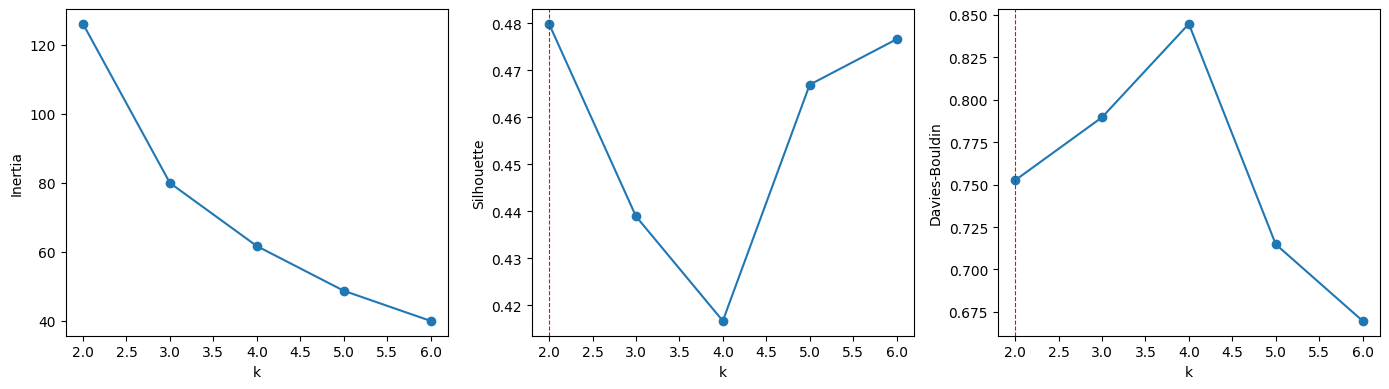

In [8]:
X_clust = score_matrix_norm

kmeans_results = {}
for k in KMEANS_K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = km.fit_predict(X_clust)
    kmeans_results[k] = {
        "model": km,
        "labels": labels,
        "silhouette": silhouette_score(X_clust, labels),
        "davies_bouldin": davies_bouldin_score(X_clust, labels),
        "inertia": km.inertia_,
    }

metrics_df = pd.DataFrame(
    [
        {
            "k": k,
            "inertia": v["inertia"],
            "silhouette": v["silhouette"],
            "davies_bouldin": v["davies_bouldin"],
        }
        for k, v in kmeans_results.items()
    ]
).set_index("k")

best_k = metrics_df["silhouette"].idxmax()
display(metrics_df.round(4))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].plot(metrics_df.index, metrics_df["inertia"], marker="o")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")

axes[1].plot(metrics_df.index, metrics_df["silhouette"], marker="o")
axes[1].axvline(best_k, color="red", linestyle="--", linewidth=0.8)
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette")

axes[2].plot(metrics_df.index, metrics_df["davies_bouldin"], marker="o")
axes[2].axvline(best_k, color="red", linestyle="--", linewidth=0.8)
axes[2].set_xlabel("k")
axes[2].set_ylabel("Davies-Bouldin")

plt.tight_layout()
plt.show()

In [9]:
kmeans_final = kmeans_results[best_k]["model"]
raw_labels = kmeans_final.labels_

pnn_rates = {}
for c in range(best_k):
    mask = raw_labels == c
    pnn_rates[c] = preds_anom["pnn"][mask].mean() if mask.sum() > 0 else 0.0

sorted_by_pnn = sorted(pnn_rates, key=pnn_rates.get, reverse=True)
remap = {old: new for new, old in enumerate(sorted_by_pnn)}
cluster_labels = np.array([remap[c] for c in raw_labels])

cluster_names = {}
for new_c in range(best_k):
    old_c = sorted_by_pnn[new_c]
    rate = pnn_rates[old_c]
    if new_c == 0:
        cluster_names[new_c] = f"C0 - Spoofing-aligned (PNN rate={rate:.1%})"
    else:
        cluster_names[new_c] = f"C{new_c} - General anomaly {new_c}"

mapping_df = pd.DataFrame(
    {
        "cluster": [cluster_names[c] for c in range(best_k)],
        "size": [(cluster_labels == c).sum() for c in range(best_k)],
    }
)
display(mapping_df)

,cluster,size
0,C0 - Spoofing-aligned (PNN rate=1.4%),3128
1,C1 - General anomaly 1,1891


In [10]:
from sklearn.cluster import HDBSCAN as _HDBSCAN
from sklearn.metrics import adjusted_rand_score

min_cluster_size = max(5, n_anom_total // 20)
hdbscan_model = _HDBSCAN(min_cluster_size=min_cluster_size)
hdbscan_labels = hdbscan_model.fit_predict(X_clust)
n_hdb_clusters = len(set(hdbscan_labels)) - (1 if -1 in hdbscan_labels else 0)

mask_valid = hdbscan_labels != -1
sil_hdb = np.nan
if mask_valid.sum() >= 2 and n_hdb_clusters >= 2:
    sil_hdb = silhouette_score(X_clust[mask_valid], hdbscan_labels[mask_valid])

agg = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
agg_labels = agg.fit_predict(X_clust)
sil_agg = silhouette_score(X_clust, agg_labels)

ari = adjusted_rand_score(cluster_labels, agg_labels)
ari_hdb = np.nan
if n_hdb_clusters >= 2 and mask_valid.sum() > 0:
    ari_hdb = adjusted_rand_score(
        cluster_labels[mask_valid], hdbscan_labels[mask_valid]
    )

comparison_df = pd.DataFrame(
    {
        "method": ["KMeans", "HDBSCAN", "Agglomerative"],
        "n_clusters": [best_k, n_hdb_clusters, best_k],
        "silhouette": [kmeans_results[best_k]["silhouette"], sil_hdb, sil_agg],
        "ARI_vs_KMeans": [1.0, ari_hdb, ari],
    }
)
display(comparison_df.round(4))

,method,n_clusters,silhouette,ARI_vs_KMeans
0,KMeans,2,0.4799,1.0000
1,HDBSCAN,2,0.6137,0.1961
2,Agglomerative,2,0.4938,0.5822


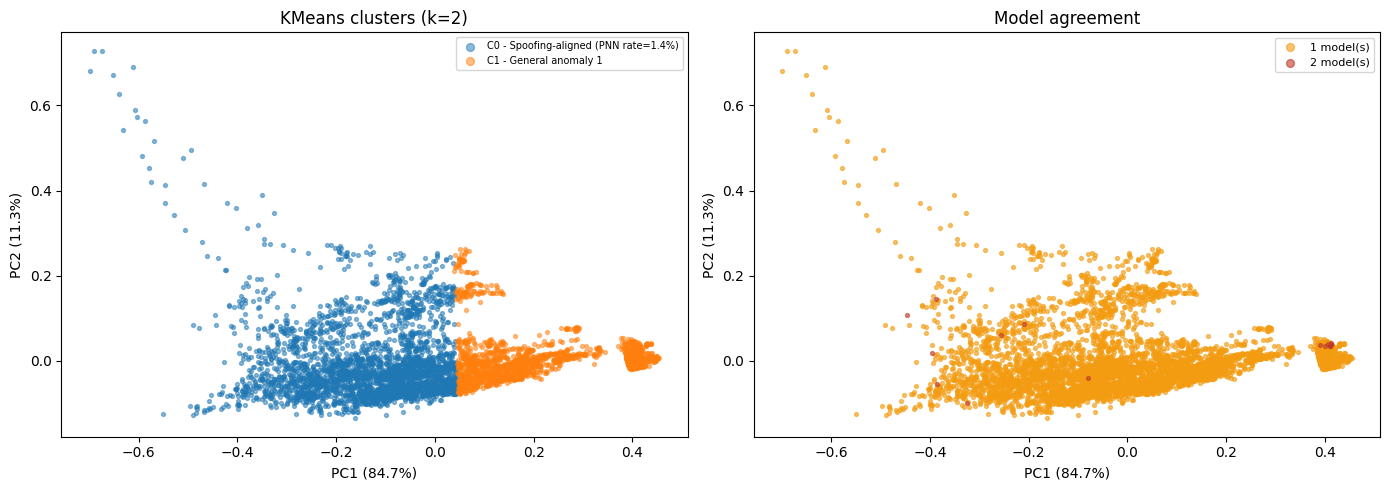

In [11]:
CLUSTER_COLORS = plt.rcParams["axes.prop_cycle"].by_key()["color"][:best_k]

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_clust)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for c in range(best_k):
    mask = cluster_labels == c
    axes[0].scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        s=8,
        alpha=0.5,
        color=CLUSTER_COLORS[c],
        label=cluster_names[c],
    )
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
axes[0].set_title(f"KMeans clusters (k={best_k})")
axes[0].legend(fontsize=7, markerscale=2)

agreement_colors = {1: "#f39c12", 2: "#c0392b", 3: "#008000"}
n_flagged_anom = n_models_flagged[anom_indices]
for n_models in sorted(set(n_flagged_anom)):
    if n_models == 0:
        continue
    mask = n_flagged_anom == n_models
    axes[1].scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        s=8,
        alpha=0.6,
        color=agreement_colors.get(n_models, "#555555"),
        label=f"{n_models} model(s)",
    )
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
axes[1].set_title("Model agreement")
axes[1].legend(fontsize=8, markerscale=2)

plt.tight_layout()
plt.show()

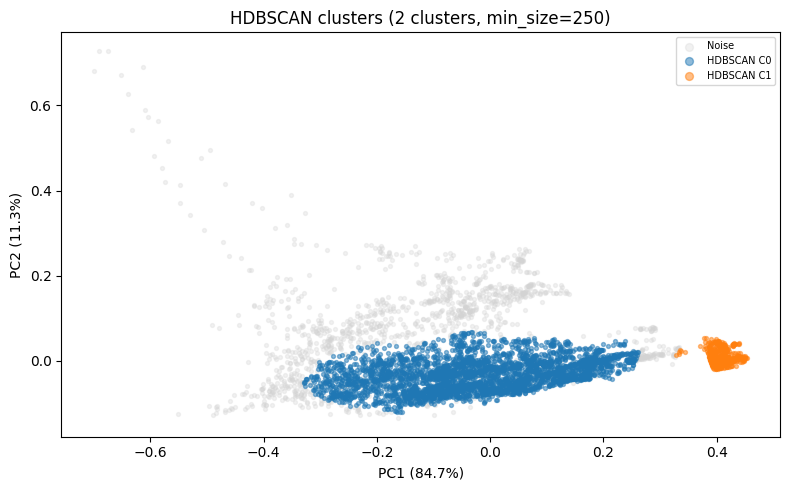

In [12]:
# HDBSCAN PCA scatter
hdb_unique = sorted(set(hdbscan_labels))
hdb_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

fig, ax = plt.subplots(figsize=(8, 5))
for lbl in hdb_unique:
    mask = hdbscan_labels == lbl
    if lbl == -1:
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1], s=8, alpha=0.3, color="lightgrey", label="Noise")
    else:
        ax.scatter(
            X_pca[mask, 0], X_pca[mask, 1],
            s=8, alpha=0.5,
            color=hdb_colors[lbl % len(hdb_colors)],
            label=f"HDBSCAN C{lbl}",
        )
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
ax.set_title(f"HDBSCAN clusters ({n_hdb_clusters} clusters, min_size={min_cluster_size})")
ax.legend(fontsize=7, markerscale=2)
plt.tight_layout()
plt.show()


,N,Share (%),ocsvm_score_mean,ocsvm_det_rate,pnn_score_mean,pnn_det_rate,prae_score_mean,prae_det_rate
Cluster,,,,,,,,
C0 - Spoofing-aligned (PNN rate=1.4%),3128,62.32,0.4254,0.0000,0.9879,0.0144,0.1483,0.9882
C1 - General anomaly 1,1891,37.68,0.7783,0.3205,0.9972,0.0016,0.0693,0.6822


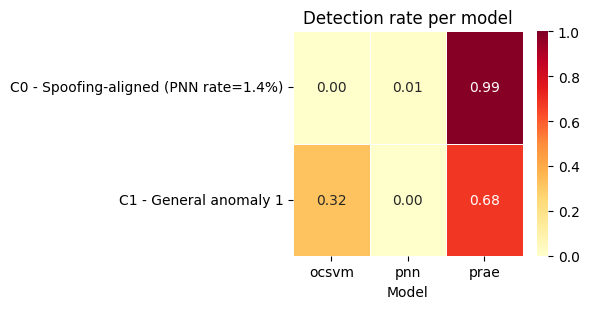

In [13]:
profile_rows = []
for c in range(best_k):
    mask = cluster_labels == c
    row = {
        "Cluster": cluster_names[c],
        "N": int(mask.sum()),
        "Share (%)": round(100 * mask.sum() / n_anom_total, 2),
    }
    for j, mt in enumerate(MODEL_TYPES):
        short = mt.replace("transformer_ocsvm", "ocsvm")
        row[f"{short}_score_mean"] = round(float(score_matrix_norm[mask, j].mean()), 4)
        row[f"{short}_det_rate"] = round(float(preds_anom[mt][mask].mean()), 4)
    profile_rows.append(row)

profile_df = pd.DataFrame(profile_rows).set_index("Cluster")
display(profile_df)

det_cols = [c for c in profile_df.columns if c.endswith("_det_rate")]
det_df = profile_df[det_cols].rename(
    columns={c: c.replace("_det_rate", "") for c in det_cols}
)
fig, ax = plt.subplots(figsize=(6, 0.6 * best_k + 2))
sns.heatmap(
    det_df.astype(float),
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    vmin=0,
    vmax=1,
    ax=ax,
    linewidths=0.5,
)
ax.set_title("Detection rate per model")
ax.set_xlabel("Model")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

In [14]:
global_mean = feat_anom.mean()
global_std = feat_anom.std().replace(0, 1e-10)

summary_rows = []
for c in range(best_k):
    mask = cluster_labels == c
    n_c = int(mask.sum())

    if mask.any():
        period_counts = pd.Series(period_anom[mask]).value_counts()
        dominant_period = period_counts.idxmax() if not period_counts.empty else "-"
        c_mean = feat_anom.iloc[mask].mean()
        top_feat = ((c_mean - global_mean) / global_std).abs().idxmax()
    else:
        dominant_period = "-"
        top_feat = "-"

    pnn_rate = float(preds_anom["pnn"][mask].mean()) if mask.any() else 0.0
    ocsvm_rate = (
        float(preds_anom["transformer_ocsvm"][mask].mean()) if mask.any() else 0.0
    )
    prae_rate = float(preds_anom["prae"][mask].mean()) if mask.any() else 0.0

    if pnn_rate >= 0.5:
        hint = "spoofing-type"
    elif ocsvm_rate >= 0.5 and prae_rate >= 0.5:
        hint = "general (OC-SVM + PRAE)"
    elif ocsvm_rate >= 0.5:
        hint = "general (OC-SVM)"
    elif prae_rate >= 0.5:
        hint = "general (PRAE)"
    else:
        hint = "mixed"

    summary_rows.append(
        {
            "Cluster": cluster_names[c],
            "N": n_c,
            "Share (%)": round(100 * n_c / n_anom_total, 2),
            "OC-SVM det.": round(ocsvm_rate, 3),
            "PNN det.": round(pnn_rate, 3),
            "PRAE det.": round(prae_rate, 3),
            "Dominant period": dominant_period,
            "Top feature": top_feat,
            "Interpretation": hint,
        }
    )

summary_df = pd.DataFrame(summary_rows).set_index("Cluster")
display(summary_df)

,N,Share (%),OC-SVM det.,PNN det.,PRAE det.,Dominant period,Top feature,Interpretation
Cluster,,,,,,,,
C0 - Spoofing-aligned (PNN rate=1.4%),3128,62.32,0.00,0.014,0.988,1st_hour,volatility_50,general (PRAE)
C1 - General anomaly 1,1891,37.68,0.32,0.002,0.682,1st_hour,volatility_50,general (PRAE)
